# Data Drift Examples

Using real churn data to understand what drift looks like and how to detect it.

We simulate drift by splitting the dataset in two halves and then shifting one of them. This keeps the example close to a real monitoring workflow, but still easy to inspect.

### Sections
1. Load data and split into "training" vs "production" sets
2. Visualise drift on key features
3. Measure drift with PSI and KS test
4. Detect a new category appearing
5. Detect a data pipeline issue with missing values


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the sample data
df = pd.read_parquet('../sample_data_from_redshift/sample.parquet')

# Convert a few columns that sometimes arrive as object/string
df['topup_total_value'] = pd.to_numeric(df['topup_total_value'], errors='coerce')
df['topup_avg_value']   = pd.to_numeric(df['topup_avg_value'], errors='coerce')
df['topup_cv_value']    = pd.to_numeric(df['topup_cv_value'], errors='coerce')
df['topup_days_since_last'] = pd.to_numeric(df['topup_days_since_last'], errors='coerce')
df['gap_since_prev_expiry'] = pd.to_numeric(df['gap_since_prev_expiry'], errors='coerce')
df['contract_number'] = pd.to_numeric(df['contract_number'], errors='coerce')
df['n_prev_contracts'] = pd.to_numeric(df['n_prev_contracts'], errors='coerce')
df['n_dias_subscricao'] = pd.to_numeric(df['n_dias_subscricao'], errors='coerce')

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print(f"Churn rate: {df['churn'].mean():.1%}")

Loaded 103,397 rows x 58 columns
Churn rate: 36.7%


## 1. Split into "training" and "production" sets

We take the first 50% of rows as the **training baseline** and treat the second half as **production**.

Then we manually shift a few features so the drift is obvious enough to study.

In [2]:
np.random.seed(42)

# Training baseline — first half of the data
train = df.iloc[:len(df)//2].copy()

# Production dataset — second half, with simulated drift applied
prod = df.iloc[len(df)//2:].copy()

# --- Simulate drift ---

# 1. past_churns: customers are more loyal now, fewer past churns
#    (e.g. company ran a successful retention campaign)
prod['past_churns'] = (prod['past_churns'] * 0.6).astype(int)

# 2. topup_total_value: customers are topping up more (price increase drove higher spend)
prod['topup_total_value'] = prod['topup_total_value'] * 2.5

# 3. n_prev_contracts: more customers are renewals, not first-timers
prod['n_prev_contracts'] = np.ceil(prod['n_prev_contracts'] * 1.6).astype(int)

# 4. n_dias_subscricao: newer subscriptions dominate the customer base
prod['n_dias_subscricao'] = (prod['n_dias_subscricao'] * 0.6).astype(int)

# 5. contract_number: customers are further along in their contract history
prod['contract_number'] = np.ceil(prod['contract_number'] * 1.4).astype(int)

print(f"Training set:   {len(train):,} rows")
print(f"Production set: {len(prod):,} rows")
print()
print("Feature        | Train mean | Prod mean  | Change")
print("-" * 55)
for col in ['past_churns', 'topup_total_value', 'n_prev_contracts', 'n_dias_subscricao', 'contract_number']:
    t_mean = train[col].mean()
    p_mean = prod[col].mean()
    pct = (p_mean - t_mean) / t_mean * 100
    print(f"{col:<22} | {t_mean:>10.1f} | {p_mean:>10.1f} | {pct:+.0f}%")

Training set:   51,698 rows
Production set: 51,699 rows

Feature        | Train mean | Prod mean  | Change
-------------------------------------------------------
past_churns            |        5.5 |        3.0 | -46%
topup_total_value      |    14220.9 |    35636.1 | +151%
n_prev_contracts       |       17.5 |       28.4 | +62%
n_dias_subscricao      |        9.3 |        5.2 | -44%
contract_number        |       17.5 |       24.9 | +42%


## 2. Visualise drift

The easiest first check is a chart.

If the training and production distributions look different, the model is receiving inputs that do not look like the data it learned from.

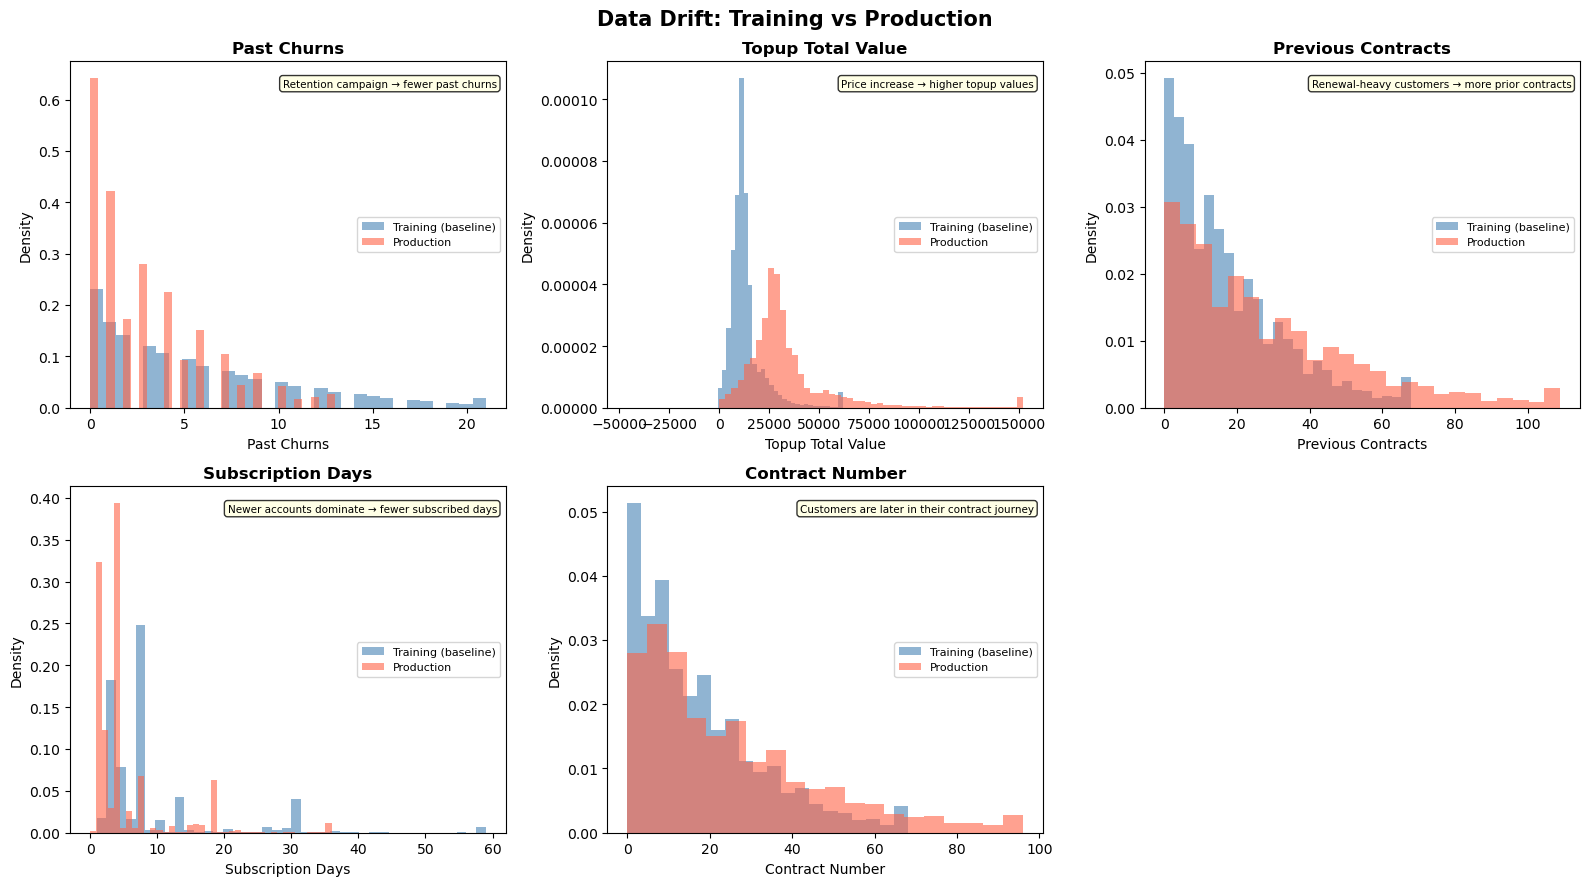

In [3]:
features = [
    ('past_churns', 'Past Churns', 30, 'Retention campaign → fewer past churns'),
    ('topup_total_value', 'Topup Total Value', 50, 'Price increase → higher topup values'),
    ('n_prev_contracts', 'Previous Contracts', 25, 'Renewal-heavy customers → more prior contracts'),
    ('n_dias_subscricao', 'Subscription Days', 40, 'Newer accounts dominate → fewer subscribed days'),
    ('contract_number', 'Contract Number', 20, 'Customers are later in their contract journey'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Data Drift: Training vs Production', fontsize=15, fontweight='bold')

for ax, (col, label, bins, reason) in zip(axes.flatten(), features):
    t_vals = train[col].dropna().clip(upper=train[col].quantile(0.99))
    p_vals = prod[col].dropna().clip(upper=prod[col].quantile(0.99))

    ax.hist(t_vals, bins=bins, alpha=0.6, color='steelblue', density=True, label='Training (baseline)')
    ax.hist(p_vals, bins=bins, alpha=0.6, color='tomato',    density=True, label='Production')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # Annotate with the business reason
    ax.text(0.98, 0.95, reason, transform=ax.transAxes,
            fontsize=7.5, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

for ax in axes.flatten()[len(features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Measure drift with PSI and KS test

Charts are useful for understanding, but in production we also need numbers so we can trigger alerts automatically.

**PSI (Population Stability Index)**
- Measures how big the overall shift is
- `< 0.1` -> stable
- `0.1-0.25` -> moderate shift, investigate
- `> 0.25` -> significant drift

**KS test (Kolmogorov-Smirnov)**
- Compares two cumulative distributions
- Higher KS statistic = bigger gap between the two curves
- `p-value < 0.05` -> the distributions are statistically different

Beginner shortcut:
- PSI answers: **how big is the shift?**
- KS p-value answers: **is the shift statistically significant?**


In [4]:
def compute_psi(baseline, production, bins=10):
    """
    Compute PSI between baseline and production distributions.

    PSI = sum((prod_pct - base_pct) * ln(prod_pct / base_pct))
    """
    # Use baseline quantiles so each bucket starts with a similar number of
    # training examples. Then open the first/last buckets so new extreme
    # production values are still counted instead of dropped.
    breakpoints = np.quantile(baseline, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return 0.0

    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    base_counts, _ = np.histogram(baseline, bins=breakpoints)
    prod_counts, _ = np.histogram(production, bins=breakpoints)

    epsilon = 1e-6
    base_pct = base_counts / base_counts.sum() + epsilon
    prod_pct = prod_counts / prod_counts.sum() + epsilon

    return np.sum((prod_pct - base_pct) * np.log(prod_pct / base_pct))


def psi_label(psi):
    if psi < 0.1:
        return "STABLE"
    elif psi < 0.25:
        return "MODERATE SHIFT"
    else:
        return "SIGNIFICANT DRIFT"


# Compute PSI and KS for the main high-priority numeric features
features_to_check = ['past_churns', 'topup_total_value', 'n_prev_contracts', 'n_dias_subscricao', 'contract_number']

print(f"{'Feature':<25} {'PSI':>6}  {'PSI Label':<20} {'KS stat':>8}  {'KS p-value':>10}  {'Drifted?'}")
print("-" * 88)

for col in features_to_check:
    baseline   = train[col].dropna().values
    production = prod[col].dropna().values

    psi = compute_psi(baseline, production)
    ks_stat, p_value = stats.ks_2samp(baseline, production)
    # For this notebook, flag drift if PSI is moderate+ or the KS test is significant.
    drifted = "YES" if psi > 0.1 or p_value < 0.05 else "no"

    print(f"{col:<25} {psi:>6.3f}  {psi_label(psi):<20} {ks_stat:>8.3f}  {p_value:>10.4f}  {drifted}")

Feature                      PSI  PSI Label             KS stat  KS p-value  Drifted?
----------------------------------------------------------------------------------------
past_churns                0.427  SIGNIFICANT DRIFT       0.218      0.0000  YES
topup_total_value          2.712  SIGNIFICANT DRIFT       0.700      0.0000  YES
n_prev_contracts           0.244  MODERATE SHIFT          0.198      0.0000  YES
n_dias_subscricao          2.493  SIGNIFICANT DRIFT       0.385      0.0000  YES
contract_number            0.149  MODERATE SHIFT          0.147      0.0000  YES


## 4. Categorical drift — a new category appears

Numeric drift is easy to measure. But categorical features drift too.

A common real-world case is a brand new product type appearing in production. The model never saw it during training, so predictions on those rows can become less reliable.

Training — tipo_produto_actual distribution:
tipo_produto_actual
tafacil7    0.520736
normal      0.410229
tafacil     0.069036

Production — tipo_produto_actual distribution:
tipo_produto_actual
tafacil7           0.490880
normal             0.390510
tafacil            0.069015
tafacil_premium    0.049595

New categories in production (not seen at training): {'tafacil_premium'}
-> These rows may be harder for the model to handle because this category never appeared in training.


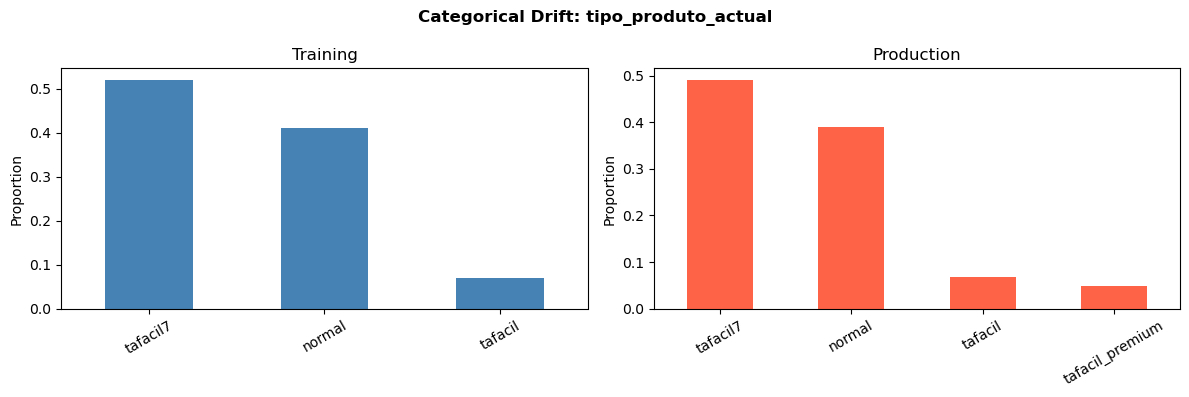

In [5]:
# Baseline: only the original product types
print("Training — tipo_produto_actual distribution:")
train_cats = train['tipo_produto_actual'].value_counts(normalize=True)
print(train_cats.to_string())

# Production: inject a new product type "tafacil_premium" that didn't exist at training
prod_cat = prod.copy()
# Replace 5% of rows with a brand new category
new_cat_mask = np.random.random(len(prod_cat)) < 0.05
prod_cat.loc[new_cat_mask, 'tipo_produto_actual'] = 'tafacil_premium'

print("\nProduction — tipo_produto_actual distribution:")
prod_cats = prod_cat['tipo_produto_actual'].value_counts(normalize=True)
print(prod_cats.to_string())

# Detect: which categories are new in production?
new_categories = set(prod_cats.index) - set(train_cats.index)
print(f"\nNew categories in production (not seen at training): {new_categories}")
print("-> These rows may be harder for the model to handle because this category never appeared in training.")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Categorical Drift: tipo_produto_actual', fontweight='bold')

train_cats.plot(kind='bar', ax=axes[0], color='steelblue', title='Training')
prod_cats.plot(kind='bar',  ax=axes[1], color='tomato',    title='Production')

for ax in axes:
    ax.set_ylabel('Proportion')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Data pipeline issue — missing value spike

Not all drift is caused by real-world behaviour change.

Sometimes a pipeline breaks and starts producing nulls for a feature. This is one of the most common production ML issues, and a simple missing-rate check catches it quickly.

Feature                       Train null%  Prod null%  Alert?
-----------------------------------------------------------------
topup_avg_value                      0.1%       39.9%  ALERT
gap_since_prev_expiry                4.7%      100.0%  ALERT
topup_total_value                    0.0%        0.0%  ok
n_prev_contracts                     0.0%        0.0%  ok


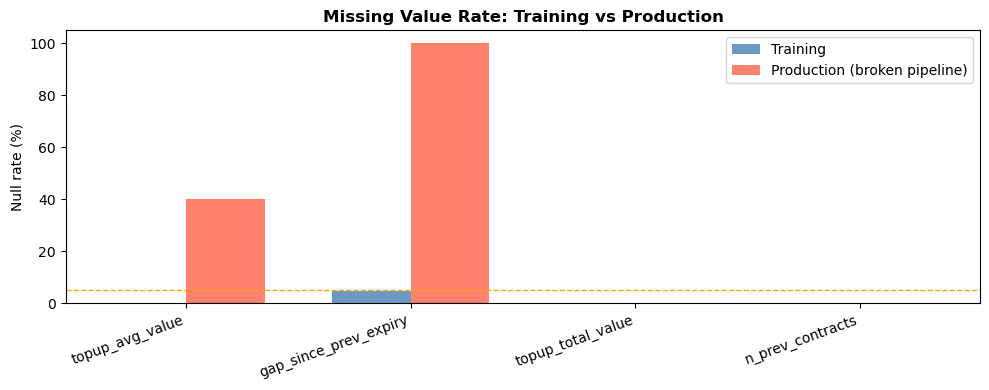

In [6]:
# Simulate a broken pipeline: topup_avg_value starts returning nulls for 40% of rows
prod_broken = prod.copy()
broken_mask = np.random.random(len(prod_broken)) < 0.40
prod_broken.loc[broken_mask, 'topup_avg_value'] = np.nan

# Also simulate gap_since_prev_expiry going completely missing (upstream join broke)
prod_broken['gap_since_prev_expiry'] = np.nan

# Compare missing rates
features_to_check = ['topup_avg_value', 'gap_since_prev_expiry', 'topup_total_value', 'n_prev_contracts']

print(f"{'Feature':<28} {'Train null%':>12}  {'Prod null%':>10}  {'Alert?'}")
print("-" * 65)

for col in features_to_check:
    train_null = train[col].isna().mean() * 100
    prod_null  = prod_broken[col].isna().mean() * 100
    # Alert if null rate increased by more than 5 percentage points
    alert = "ALERT" if (prod_null - train_null) > 5 else "ok"
    print(f"{col:<28} {train_null:>11.1f}%  {prod_null:>9.1f}%  {alert}")

# Visualise missing rates as a bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(features_to_check))
width = 0.35

train_nulls = [train[col].isna().mean() * 100 for col in features_to_check]
prod_nulls  = [prod_broken[col].isna().mean() * 100 for col in features_to_check]

ax.bar(x - width/2, train_nulls, width, label='Training', color='steelblue', alpha=0.8)
ax.bar(x + width/2, prod_nulls,  width, label='Production (broken pipeline)', color='tomato', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(features_to_check, rotation=20, ha='right')
ax.set_ylabel('Null rate (%)')
ax.set_title('Missing Value Rate: Training vs Production', fontweight='bold')
ax.legend()
ax.axhline(y=5, color='orange', linestyle='--', linewidth=1, label='Alert threshold')
plt.tight_layout()
plt.show()

## Summary

What we demonstrated:

1. **Numeric drift** (`past_churns`, `topup_total_value`, `n_prev_contracts`, `n_dias_subscricao`, `contract_number`)
   - Real-world behaviour changes shift the distribution of key features
   - We detect it visually and with PSI + KS

2. **Categorical drift** (`tipo_produto_actual`)
   - A new product type appears that the model never saw during training
   - We detect it by comparing category sets

3. **Pipeline drift** (`topup_avg_value`, `gap_since_prev_expiry`)
   - An upstream data issue creates unexpected nulls
   - We detect it by comparing missing-value rates

In production, these checks usually run on a schedule. When a violation is detected, the team investigates and decides whether the fix is a pipeline repair, closer monitoring, or retraining.
